# PCA e Clustering
Perform PCA and clustering on the dataset extracted from `/proc/meminfo`.

## PCA - Principal Component Analysis
Pre-processing analysis used to reduce the number of columns with a set of independent ones. These new columns have $mean = 0$ and $variance = 1$.

In [2]:
import pandas as pd

fname = "meminfo.csv"

# read data
df = pd.read_csv(fname)

# exclude Timestamp column
df = df.iloc[:, df.columns != "Timestamp"]

print("Columns (w/out timestamp):", len(df.columns))

Columns (w/out timestamp): 57


In [3]:
from sklearn.decomposition import PCA
from scipy.stats import zscore

# n components
n_components = 9

# create pca object
pca = PCA(n_components=n_components)

# normalize data using zscore. Fill with 0 constant columns
norm_df = df.apply(zscore, ddof=1).dropna(axis=1)

# create principal components passing all data as array of arrays
principal_components = pca.fit_transform(norm_df.values)

pca_df = pd.DataFrame(principal_components)

pca_df[0] *= -1

pca_df.head()

,0,1,2,3,4,5,6,7,8
0,-14.380459,-6.651165,-2.968946,7.536670,2.689535,-2.829893,-0.964134,0.107165,0.908087
1,-9.222016,-2.861578,0.608021,10.470450,-1.747175,-0.766576,-1.068776,0.941850,-0.257822
2,-8.860575,-2.915218,0.031696,9.920473,-0.860039,2.833280,0.080132,-0.148644,1.241763
3,-11.796754,-4.844521,-1.006412,8.915599,2.146238,0.748067,-0.773982,0.580075,0.619853
4,-10.334131,-3.261281,0.232407,9.842326,0.178605,0.519677,-0.575427,0.285316,0.803131


In [4]:
# calculate explained variance and choose number of components
explained_var = sum(pca.explained_variance_ratio_)

print("explained variance", explained_var*100, "%", "; loss", (1-explained_var)*100, "%")

explained variance 92.56618453776223 % ; loss 7.433815462237769 %


### Clustering
Now perform clustering on principal components using hierarchical clustering method.

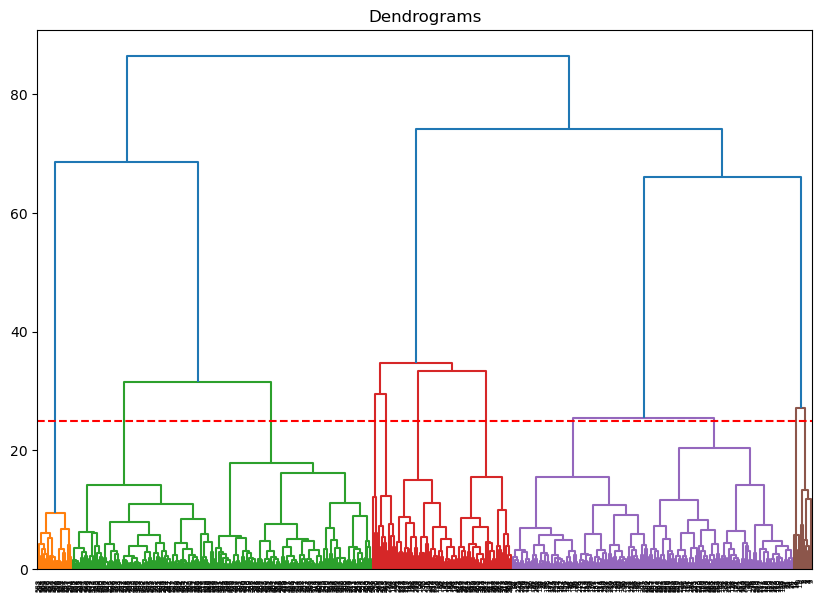

In [5]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendrograms")  
dend = shc.dendrogram(shc.linkage(principal_components, method='ward'))
plt.axhline(y=25, color='r', linestyle='--')

In [6]:
from sklearn.cluster import AgglomerativeClustering

# number of cluster
n_clusters = 11

# perform clustering with ward as linkage method
clustering = AgglomerativeClustering(n_clusters=n_clusters)

clusters = clustering.fit_predict(principal_components)

### Calculate total deviance loss

In [7]:
import numpy as np

# calculate total deviance from original dataset
tot_dev = (norm_df - norm_df.mean()).pow(2).sum().sum()

print("total deviance:", tot_dev)

# calculate deviance from pca
pca_dev = (pca_df - pca_df.mean()).pow(2).sum().sum()

print("pca deviance:", pca_dev, ";", (pca_dev / tot_dev)*100, "%")

# calculate intra and inter cluster deviation
intra_cluster_dev = np.zeros(n_clusters)
inter_cluster_dev = np.zeros(n_clusters)

for cluster in range(n_clusters):
    centroid = pca_df.loc[clusters == cluster].mean()
    
    n_elements = pca_df.loc[clusters == cluster].shape[0]

    # compute the deviation as the squared distance from the centroid
    local_intra = (centroid - pca_df.loc[clusters == cluster]).pow(2).sum().sum()

    # compute the deviation as the squared distance from the others centrod weighted by cluster size 
    local_inter = n_elements * (centroid - pca_df.mean()).pow(2).sum()

    # add to result list
    intra_cluster_dev[cluster] = local_intra
    inter_cluster_dev[cluster] = local_inter

intra_cluster_dev = intra_cluster_dev.sum()
inter_cluster_dev = inter_cluster_dev.sum()

print((intra_cluster_dev + inter_cluster_dev) / pca_dev)

pca_and_cluster_dev = inter_cluster_dev / pca_dev
tot_lost_dev = 1 + (intra_cluster_dev - pca_dev) / tot_dev

print("total deviance lost:", tot_lost_dev * 100, "%")

total deviance: 19168.0
pca deviance: 17743.086252198253 ; 92.56618453776217 %
0.9999999999999998
total deviance lost: 27.96123100618949 %
